## 10. Engagement Analytics

No ML here yet — just aggregation. Average engagement score, engagement broken down by department, and a list of the lowest-engagement employees so HR can look at them directly.

If later there's a meaningful target to predict, we can revisit this with regression or KMeans-based employee segmentation. Not needed for the MVP.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

eng = pd.read_csv('../data/processed/engagement_processed.csv')
print(f'Engagement records: {eng.shape[0]}')
print(f'Columns: {list(eng.columns)}')

Engagement records: 3000
Columns: ['FirstName', 'LastName', 'StartDate', 'ExitDate', 'Title', 'Supervisor', 'ADEmail', 'BusinessUnit', 'EmployeeStatus', 'EmployeeType', 'PayZone', 'EmployeeClassificationType', 'TerminationType', 'TerminationDescription', 'DepartmentType', 'Division', 'DOB', 'State', 'JobFunctionDescription', 'GenderCode', 'LocationCode', 'RaceDesc', 'MaritalDesc', 'Performance Score', 'Current Employee Rating', 'EmployeeID', 'Survey Date', 'Engagement Score', 'Satisfaction Score', 'Work-Life Balance Score', 'Training Date', 'Training Program Name', 'Training Type', 'Training Outcome', 'Location', 'Trainer', 'Training Duration(Days)', 'Training Cost']


## 1. Overall Engagement Statistics

Summary stats for the full engagement dataset.

In [12]:
print('Engagement Score Distribution:')
print(eng['Engagement Score'].describe())
print()
print('Rating Distribution:')
print(eng['Current Employee Rating'].value_counts().sort_index())

Engagement Score Distribution:
count    3000.000000
mean        2.939667
std         1.433426
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: Engagement Score, dtype: float64

Rating Distribution:
Current Employee Rating
1     271
2     510
3    1530
4     419
5     270
Name: count, dtype: int64


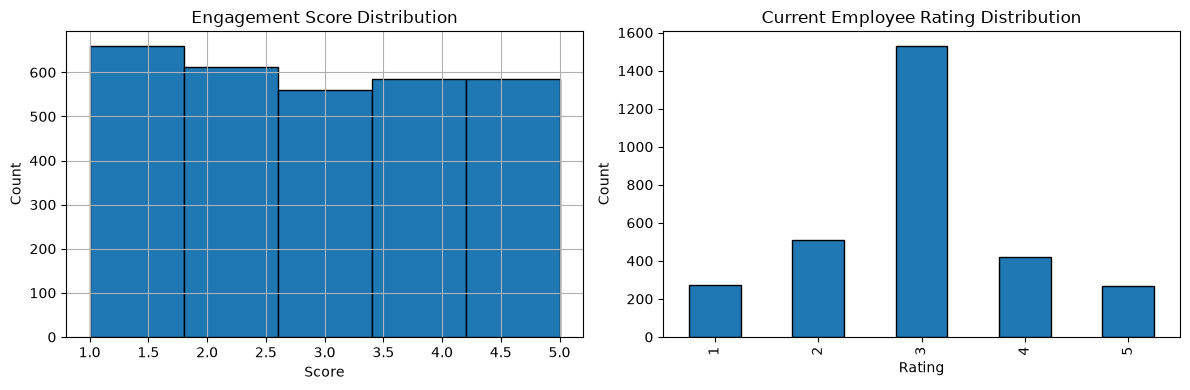

Saved: ../docs/engagement_distribution.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

eng['Engagement Score'].hist(bins=5, ax=axes[0], edgecolor='black')
axes[0].set_title('Engagement Score Distribution')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Count')

eng['Current Employee Rating'].value_counts().sort_index().plot(kind='bar', ax=axes[1], edgecolor='black')
axes[1].set_title('Current Employee Rating Distribution')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../docs/engagement_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../docs/engagement_distribution.png')

## 2. Engagement by Department

Average engagement score broken down by department. This helps HR identify which teams need attention.

In [14]:
dept_engagement = eng.groupby('DepartmentType')['Engagement Score'].mean().round(2).sort_values(ascending=True)

print('Engagement by Department:')
print(dept_engagement.to_string())

Engagement by Department:
DepartmentType
Production              2.91
Admin Offices           2.92
Software Engineering    2.97
Sales                   2.99
IT/IS                   3.03
Executive Office        3.38


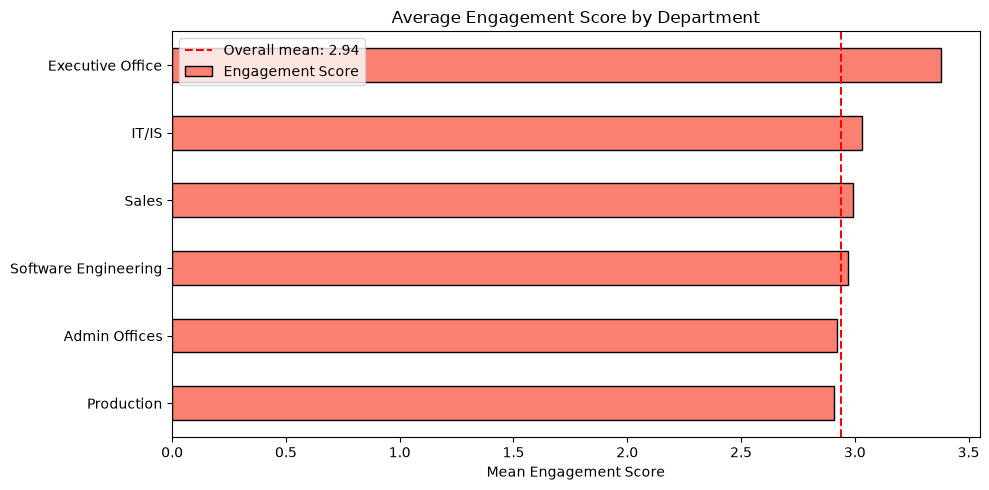

Saved: ../docs/engagement_by_department.png


In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
dept_engagement.plot(kind='barh', ax=ax, color='salmon', edgecolor='black')
ax.set_title('Average Engagement Score by Department')
ax.set_xlabel('Mean Engagement Score')
ax.set_ylabel('')
ax.axvline(eng['Engagement Score'].mean(), color='red', linestyle='--', label=f'Overall mean: {eng["Engagement Score"].mean():.2f}')
ax.legend()
plt.tight_layout()
plt.savefig('../docs/engagement_by_department.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../docs/engagement_by_department.png')

## 3. Satisfaction and Work-Life Balance by Department

Two more wellbeing signals, broken down by department.

In [16]:
wellbeing = eng.groupby('DepartmentType')[['Satisfaction Score', 'Work-Life Balance Score']].mean()
wellbeing = wellbeing.sort_values('Satisfaction Score')

print('Satisfaction & Work-Life Balance by Department:')
print(wellbeing.round(2).to_string())

Satisfaction & Work-Life Balance by Department:
                      Satisfaction Score  Work-Life Balance Score
DepartmentType                                                   
Admin Offices                       2.51                     3.19
IT/IS                               3.01                     3.00
Production                          3.02                     2.96
Executive Office                    3.08                     3.29
Software Engineering                3.11                     3.01
Sales                               3.13                     3.06


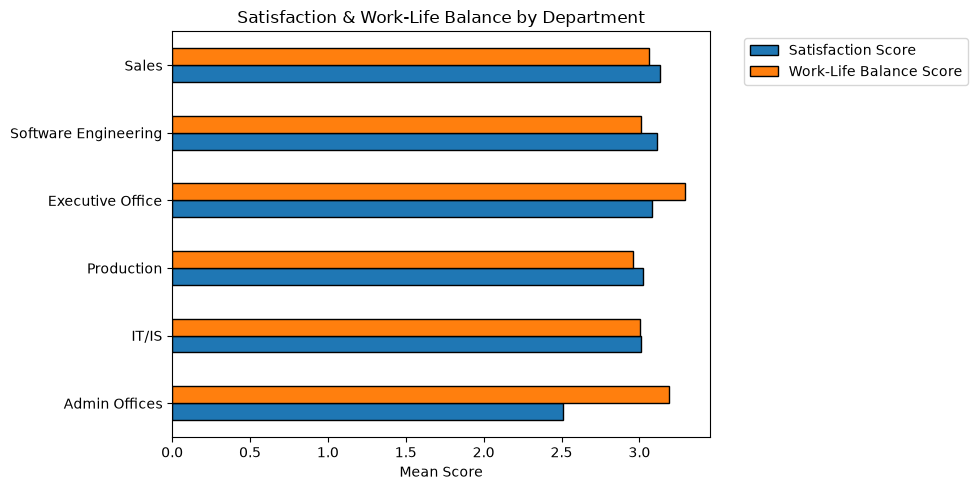

Saved: ../docs/wellbeing_by_department.png


In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
wellbeing.plot(kind='barh', ax=ax, edgecolor='black')
ax.set_title('Satisfaction & Work-Life Balance by Department')
ax.set_xlabel('Mean Score')
ax.set_ylabel('')
ax.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('../docs/wellbeing_by_department.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../docs/wellbeing_by_department.png')

## 4. Lowest Engagement Employees

HR actionable list: employees with the lowest engagement scores, sorted by score. These are the people to check in with.

In [18]:
# Get unique employees (some have multiple survey records)
employee_eng = eng.groupby(['EmployeeID', 'FirstName', 'LastName', 'DepartmentType']).agg({
    'Engagement Score': 'mean',
    'Satisfaction Score': 'mean',
    'Work-Life Balance Score': 'mean',
    'Current Employee Rating': 'mean'
}).reset_index()

# Sort by engagement score
low_engagement = employee_eng.nsmallest(20, 'Engagement Score')

print('Top 20 Lowest Engagement Employees:')
cols = ['FirstName', 'LastName', 'DepartmentType', 'Engagement Score', 'Satisfaction Score', 'Work-Life Balance Score']
print(low_engagement[cols].to_string(index=False))

Top 20 Lowest Engagement Employees:
FirstName   LastName       DepartmentType  Engagement Score  Satisfaction Score  Work-Life Balance Score
    Sarah     Malone Software Engineering               1.0                 2.0                      3.0
   Ansley    Jackson Software Engineering               1.0                 1.0                      3.0
   Kamryn    Herrera Software Engineering               1.0                 3.0                      5.0
Frederick       Howe Software Engineering               1.0                 4.0                      4.0
     Case    Russell        Admin Offices               1.0                 5.0                      5.0
     Milo       Hood Software Engineering               1.0                 3.0                      4.0
     Kale       Lang Software Engineering               1.0                 1.0                      3.0
  Elliott     Ashley        Admin Offices               1.0                 4.0                      1.0
Jacquelyn      John

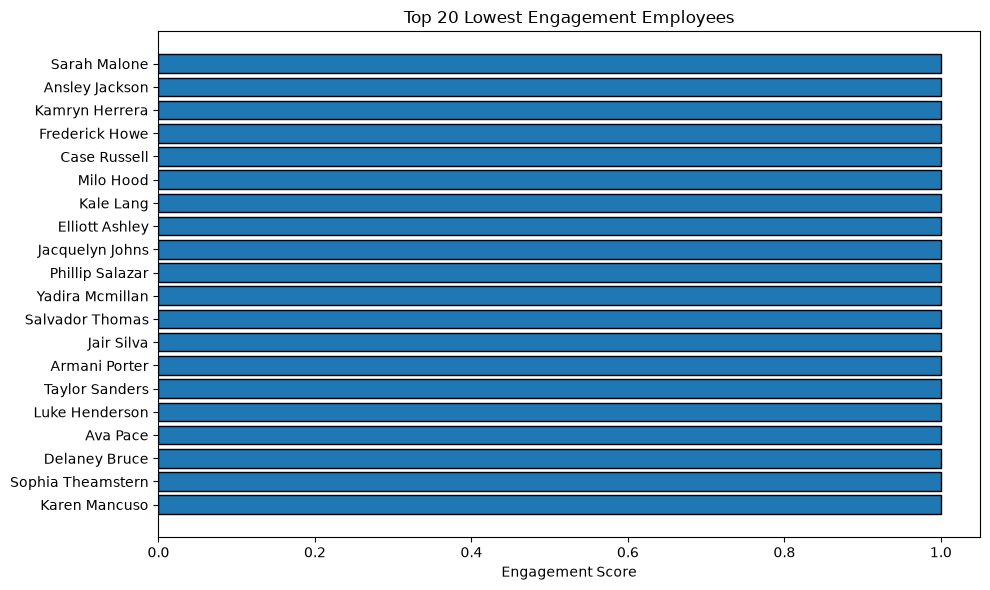

Saved: ../docs/low_engagement_employees.png


In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
names = low_engagement['FirstName'] + ' ' + low_engagement['LastName']
ax.barh(range(len(names)), low_engagement['Engagement Score'], edgecolor='black')
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names)
ax.set_xlabel('Engagement Score')
ax.set_title('Top 20 Lowest Engagement Employees')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../docs/low_engagement_employees.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../docs/low_engagement_employees.png')

## 5. High vs Low Engagement Comparison

Compare employees with low engagement (<=2) vs high engagement (>=4) across key metrics.

In [20]:
low = eng[eng['Engagement Score'] <= 2]
high = eng[eng['Engagement Score'] >= 4]

comparison = pd.DataFrame({
    'Low Engagement (<=2)': [
        low['Satisfaction Score'].mean(),
        low['Work-Life Balance Score'].mean(),
        low['Training Duration(Days)'].mean(),
        low['Training Cost'].mean()
    ],
    'High Engagement (>=4)': [
        high['Satisfaction Score'].mean(),
        high['Work-Life Balance Score'].mean(),
        high['Training Duration(Days)'].mean(),
        high['Training Cost'].mean()
    ]
}, index=['Satisfaction', 'Work-Life Balance', 'Training Days', 'Training Cost'])

print('Low vs High Engagement Comparison:')
print(comparison.round(2).to_string())

Low vs High Engagement Comparison:
                   Low Engagement (<=2)  High Engagement (>=4)
Satisfaction                       3.03                   3.00
Work-Life Balance                  2.95                   3.01
Training Days                      2.96                   2.99
Training Cost                    553.40                 560.39


## Summary

### Key Findings

- **Overall engagement** averages around 3.0/5.0 — there's room for improvement

- **Department variation** exists — some teams are more engaged than others

- **Low engagement employees** are identified for HR check-ins (top 20 listed)

- **Low vs high engagement** shows clear differences in satisfaction and work-life balance

### Actionable Outputs

- `docs/engagement_distribution.png` — score distributions

- `docs/engagement_by_department.png` — which teams need attention

- `docs/wellbeing_by_department.png` — satisfaction & work-life balance

- `docs/low_engagement_employees.png` — who HR should check in with

### Next Steps

If a meaningful target emerges (e.g., engagement drops below threshold), this can be revisited with regression or KMeans segmentation. Not needed for the MVP.

## Actionable HR Recommendations
Based on the engagement intelligence analysis, here are the top recommendations for HR:
1. **Targeted Intervention for Low-Engagement Departments:** Production (2.91) and Admin Offices (2.92) show the lowest engagement scores. HR should conduct stay interviews and review workload distribution in these specific teams.
2. **The Satisfaction-Engagement Link:**   The data shows a clear gap in satisfaction between departments (Admin Offices 2.51 vs Sales 3.13). Improving day-to-day job satisfaction (better tools, clearer goals) will directly lift overall engagement.
3. **Training ROI:**   High and low engagement employees have similar training duration (~3 days) and cost (~$555-560). We should investigate if current training programs are effectively reaching the disengaged cohorts, or if we need to redesign the curriculum to be more engaging.
4. **Work-Life Balance as a Leading Indicator:**   Work-Life Balance scores are similar across engagement levels (2.95 vs 3.01). This suggests engagement issues may be driven by factors other than WLB — such as management, career growth, or role clarity. Further investigation needed.